In [83]:
import pandas as pd
import numpy as np

In [ ]:
eu=pd.read_excel(r"C:\Users\anadi\Desktop\Europe.xlsx")

In [87]:
eu.shape

(12, 8)

In [89]:
eu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country       12 non-null     object 
 1   Area          12 non-null     int64  
 2   GDP           12 non-null     int64  
 3   Inflation     12 non-null     float64
 4   Life.expect   12 non-null     float64
 5   Military      12 non-null     float64
 6   Pop.growth    12 non-null     float64
 7   Unemployment  12 non-null     float64
dtypes: float64(5), int64(2), object(1)
memory usage: 900.0+ bytes


In [91]:
eu.head()

,Country,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
0,Austria,83871,41600,3.5,79.91,0.80,0.03,4.2
1,Belgium,30528,37800,3.5,79.65,1.30,0.06,7.2
2,Bulgaria,110879,13800,4.2,73.84,2.60,-0.80,9.6
3,Croatia,56594,18000,2.3,75.99,2.39,-0.09,17.7
4,Czech Republic,78867,27100,1.9,77.38,1.15,-0.13,8.5


In [93]:
eu1=eu.iloc[:,1:8]

In [95]:
eu1.head()

,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
0,83871,41600,3.5,79.91,0.80,0.03,4.2
1,30528,37800,3.5,79.65,1.30,0.06,7.2
2,110879,13800,4.2,73.84,2.60,-0.80,9.6
3,56594,18000,2.3,75.99,2.39,-0.09,17.7
4,78867,27100,1.9,77.38,1.15,-0.13,8.5


In [97]:
import sklearn
from sklearn.preprocessing import StandardScaler

In [99]:
scale=StandardScaler() 

In [101]:
eu2=scale.fit_transform(eu1) #eu2 is a numpy attribute#

In [103]:
eu2

array([[-3.70843368e-01,  1.30324624e+00,  1.78753078e-01,
         7.93527876e-01, -9.36230722e-01,  2.91312634e-01,
        -1.30542813e+00],
       [-8.80509856e-01,  8.94525270e-01,  1.78753078e-01,
         6.90882479e-01, -4.47337394e-01,  3.73244312e-01,
        -5.81307751e-01],
       [-1.12795029e-01, -1.68687030e+00,  1.01293411e+00,
        -1.60284735e+00,  8.23785256e-01, -1.97546380e+00,
        -2.01144551e-03],
       [-6.31461871e-01, -1.23512607e+00, -1.25127154e+00,
        -7.54048877e-01,  6.18450059e-01, -3.64140792e-02,
         1.95311359e+00],
       [-4.18654160e-01, -2.56346921e-01, -1.72794642e+00,
        -2.05290794e-01, -5.94005393e-01, -1.45656317e-01,
        -2.67522252e-01],
       [-7.60447822e-01,  8.08478751e-01, -6.55427951e-01,
         3.47415189e-01, -4.47337394e-01,  8.64834382e-01,
        -8.46818558e-01],
       [-7.40058487e-01, -9.76986518e-01,  1.96628385e+00,
        -1.70549275e+00,  2.37113264e-01, -1.56580541e+00,
         6.9797159

In [105]:
eu3=pd.DataFrame(eu2,columns=eu1.columns)

In [107]:
eu3.head()

,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
0,-0.370843,1.303246,0.178753,0.793528,-0.936231,0.291313,-1.305428
1,-0.880510,0.894525,0.178753,0.690882,-0.447337,0.373244,-0.581308
2,-0.112795,-1.686870,1.012934,-1.602847,0.823785,-1.975464,-0.002011
3,-0.631462,-1.235126,-1.251272,-0.754049,0.618450,-0.036414,1.953114
4,-0.418654,-0.256347,-1.727946,-0.205291,-0.594005,-0.145656,-0.267522


In [109]:
from sklearn.cluster import AgglomerativeClustering

In [111]:
agg_clust=AgglomerativeClustering(linkage='ward')

In [113]:
agg_clust.fit_predict(eu3)

array([1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1], dtype=int64)

In [123]:
import scipy
from scipy.cluster.hierarchy import dendrogram,linkage

In [125]:
d=linkage(eu3,method='ward')

In [127]:
d

array([[ 1.        ,  5.        ,  1.07135589,  2.        ],
       [ 0.        , 12.        ,  1.34244914,  3.        ],
       [ 7.        ,  8.        ,  1.43484082,  2.        ],
       [ 2.        ,  6.        ,  1.67892422,  2.        ],
       [10.        , 15.        ,  2.179307  ,  3.        ],
       [11.        , 13.        ,  2.76269501,  4.        ],
       [ 3.        ,  4.        ,  2.81866205,  2.        ],
       [ 9.        , 18.        ,  3.96005822,  3.        ],
       [14.        , 17.        ,  4.97537485,  6.        ],
       [16.        , 19.        ,  5.52948528,  6.        ],
       [20.        , 21.        ,  8.29663367, 12.        ]])

In [129]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Distance')

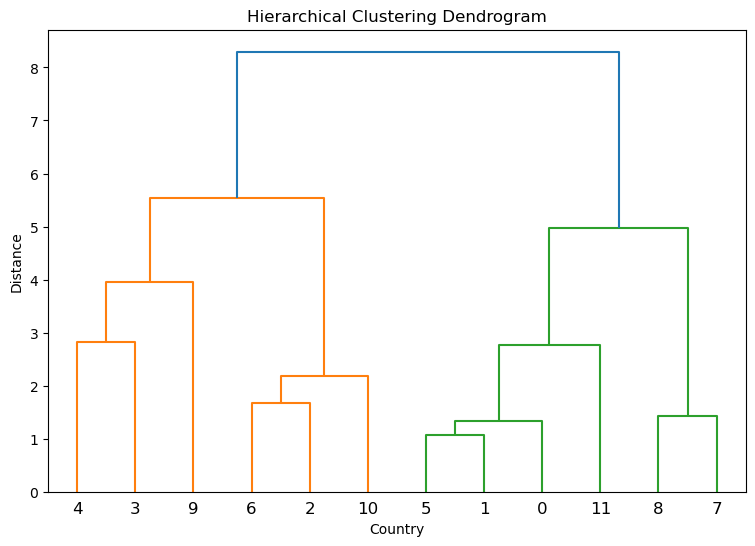

In [135]:
plt.figure(figsize=(9,6))
dendrogram(d,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country')
plt.ylabel('Distance')